# OHLC Conditional — CSV-based Analysis

Loads pre-generated samples from CSV files produced by `generate_samples.py`
and compares the generated Close paths against ground-truth Close.

No model inference is performed here — just load, parse, and analyse.

Expected CSVs (under `<GEN_DIR>/<CHECKPOINT_STEM>/`):
- `train_generated_close.csv` — generated Close paths for training windows
- `train_gt_ohlc.csv`         — ground-truth OHLC context for training windows
- `val_generated_close.csv`   — generated Close paths for validation windows
- `val_gt_ohlc.csv`           — ground-truth OHLC context for validation windows

CSV schemas
-----------
`*_generated_close.csv`: `window_idx | sample_idx | file | window_start | step_000 … step_{L-1}`

`*_gt_ohlc.csv`: `window_idx | feature | file | window_start | step_000 … step_{L-1}`

In [ ]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
CHECKPOINT_STEM = (
    "EDM_REPLICATION_CLOS_ep-474_step-42186_sd-1.0_Pm--1.2_20260601_064403\csv1024_samples10_steps200_seed50_20260601_135314"
)  # <-- sub-folder name under GEN_DIR (= checkpoint filename without .pt)

GEN_DIR = "../data/generated/final/edm"  # base directory where generate_samples.py writes

SPLIT   = "val"   # "train" | "val" | "both"  — which split(s) to analyse

appendix = "replication_Pm-1.4-Ps-1.6"  # appendix to add to output filename (e.g. for distinguishing different runs)
# ─────────────────────────────────────────────────────────────────────────────

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\3874529494.py:3: SyntaxWarning: invalid escape sequence '\c'
  "EDM_REPLICATION_CLOS_ep-500_step-44500_sd-1.0_Pm--1.4_20260530_083037\csv1024_samples10_steps200_seed50_20260601_092603"


In [94]:
# ── USER INPUTS ── unnormalization ────────────────────────────────────────────
STATS_FILE      = "../data/general/normalization_stats_SNP500_super_normalized.csv"   # path to mean/std CSV
RAW_DATA_FOLDER = "../data/SNP500_individual"        # folder of per-ticker CSVs
# ─────────────────────────────────────────────────────────────────────────────


In [95]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf

ckpt_dir = os.path.join(GEN_DIR, CHECKPOINT_STEM)
assert os.path.isdir(ckpt_dir), f"Directory not found: {ckpt_dir}"
print(f"Reading from: {ckpt_dir}")

Reading from: ../data/generated/final/edm\EDM_REPLICATION_CLOS_ep-500_step-44500_sd-1.0_Pm--1.4_20260530_083037\csv1024_samples10_steps200_seed50_20260601_092603


## 1. Load CSVs

In [96]:
def load_split(split, ckpt_dir):
    """
    Load one split's generated-close and GT-OHLC CSVs.

    Returns
    -------
    df_gen  : DataFrame  (window_idx, sample_idx, file, window_start, step_*)
    df_ohlc : DataFrame  (window_idx, feature, file, window_start, step_*)
    step_cols : list of step column names
    """
    gen_path  = os.path.join(ckpt_dir, f"{split}_generated_close.csv")
    ohlc_path = os.path.join(ckpt_dir, f"{split}_gt_ohlc.csv")

    assert os.path.isfile(gen_path),  f"Not found: {gen_path}"
    assert os.path.isfile(ohlc_path), f"Not found: {ohlc_path}"

    df_gen  = pd.read_csv(gen_path)
    df_ohlc = pd.read_csv(ohlc_path)

    step_cols = [c for c in df_gen.columns if c.startswith("step_")]
    seq_len   = len(step_cols)

    n_windows = df_gen["window_idx"].nunique()
    n_samples = df_gen["sample_idx"].nunique()
    features  = df_ohlc["feature"].unique().tolist()

    print(f"[{split}] windows={n_windows}  samples/window={n_samples}  "
          f"seq_len={seq_len}  features={features}")

    return df_gen, df_ohlc, step_cols


splits_to_run = ["train", "val"] if SPLIT == "both" else [SPLIT]
data = {}

for split in splits_to_run:
    try:
        df_gen, df_ohlc, step_cols = load_split(split, ckpt_dir)
        data[split] = (df_gen, df_ohlc, step_cols)
    except AssertionError as e:
        print(f"Skipping {split}: {e}")

[val] windows=239  samples/window=10  seq_len=512  features=['close', 'high', 'low', 'open']


## 2. Parse into NumPy arrays

Reshape DataFrames into `(n_windows, n_samples, seq_len)` for generated Close
and `(n_windows, seq_len)` per OHLC feature for ground-truth context.

In [97]:
def parse_arrays(df_gen, df_ohlc, step_cols):
    """
    Returns
    -------
    gen_3d   : (n_windows, n_samples, seq_len)  — generated Close
    gt_close : (n_windows, seq_len)             — ground-truth Close
    gt_open  : (n_windows, seq_len)
    gt_high  : (n_windows, seq_len)
    gt_low   : (n_windows, seq_len)
    window_ids : list of window_idx values (sorted)
    """
    window_ids = sorted(df_gen["window_idx"].unique())
    n_windows  = len(window_ids)
    n_samples  = df_gen["sample_idx"].nunique()
    seq_len    = len(step_cols)

    gen_3d = np.zeros((n_windows, n_samples, seq_len), dtype=np.float32)
    for wi, wid in enumerate(window_ids):
        sub = df_gen[df_gen["window_idx"] == wid].sort_values("sample_idx")
        gen_3d[wi] = sub[step_cols].to_numpy(dtype=np.float32)

    def gt_feat(feat_name):
        sub = df_ohlc[df_ohlc["feature"] == feat_name].sort_values("window_idx")
        return sub[step_cols].to_numpy(dtype=np.float32)   # (n_windows, seq_len)

    gt_open  = gt_feat("open")
    gt_high  = gt_feat("high")
    gt_low   = gt_feat("low")
    gt_close = gt_feat("close")

    return gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids


parsed = {}
for split, (df_gen, df_ohlc, step_cols) in data.items():
    parsed[split] = parse_arrays(df_gen, df_ohlc, step_cols)
    gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids = parsed[split]
    print(f"[{split}] gen_3d={gen_3d.shape}  gt_close={gt_close.shape}")

[val] gen_3d=(239, 10, 512)  gt_close=(239, 512)


---
## Analyses

The cells below run on the **first available split** by default.  
Change `ANALYSIS_SPLIT` to switch between `"train"` / `"val"`.

In [98]:
ANALYSIS_SPLIT = splits_to_run[0]   # change to "val" if needed

gen_3d, gt_close, gt_open, gt_high, gt_low, window_ids = parsed[ANALYSIS_SPLIT]
n_windows, n_samples, seq_len = gen_3d.shape
steps = np.arange(seq_len)

# Flat 2-D views for distribution-level comparisons
all_gen_close = gen_3d.reshape(n_windows * n_samples, seq_len)   # (N*B, L)
all_gt_close  = np.repeat(gt_close, n_samples, axis=0)           # (N*B, L)
all_gt_high   = np.repeat(gt_high,  n_samples, axis=0)
all_gt_low    = np.repeat(gt_low,   n_samples, axis=0)

print(f"Split         : {ANALYSIS_SPLIT}")
print(f"n_windows     : {n_windows}")
print(f"n_samples     : {n_samples}")
print(f"seq_len       : {seq_len}")
print(f"all_gen_close : {all_gen_close.shape}")

Split         : val
n_windows     : 239
n_samples     : 10
seq_len       : 512
all_gen_close : (2390, 512)


## 3. Sample path overlays

For each shown window: ground-truth OHL band + GT Close (top row) vs
GT OHL band + all generated Close samples (bottom row).

In [99]:
N_SHOW  = min(n_windows, 4)   # number of windows to print individually

for w in range(N_SHOW):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax in axes:
        ax.fill_between(steps, gt_low[w], gt_high[w],
                        alpha=0.15, color="gray", label="[L, H] band")
        ax.plot(steps, gt_open[w],  color="steelblue", lw=1.0, ls="--", alpha=0.7, label="Open")
        ax.plot(steps, gt_high[w],  color="green",     lw=1.0, ls="--", alpha=0.7, label="High")
        ax.plot(steps, gt_low[w],   color="red",       lw=1.0, ls="--", alpha=0.7, label="Low")
        ax.set_xlabel("step")
        ax.set_ylabel("normalised price")

    # Left panel: ground-truth Close
    axes[0].plot(steps, gt_close[w], color="black", lw=1.8, label="GT Close")
    axes[0].set_title(f"Window {window_ids[w]} — Ground Truth Close")
    axes[0].legend(fontsize=8, loc="upper left")

    # Right panel: all generated Close samples
    for s in range(n_samples):
        axes[1].plot(steps, gen_3d[w, s], color="tab:orange", lw=0.9, alpha=0.5)
    axes[1].set_title(f"Window {window_ids[w]} — Generated Close ({n_samples} samples)")

    plt.suptitle(
        f"[{ANALYSIS_SPLIT}] Window {window_ids[w]} — OHL context + generated/GT Close",
        y=1.02, fontsize=12
    )
    plt.tight_layout()
    plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\2234422535.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. OHLC constraint satisfaction

Checks whether the generated Close satisfies `L ≤ Close ≤ H`.

> Note: data are normalised column-wise, so this constraint can be broken locally even for perfectly generated samples — treat the rate as a diagnostic, not an absolute criterion.

  OHLC CONSTRAINT  L ≤ Close ≤ H
Metric                               Generated   GT (ref)
-------------------------------------------------------
Step-wise satisfaction rate             0.1013     0.0856
Fully valid samples                     0.0000     0.0000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\2855459146.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 3))


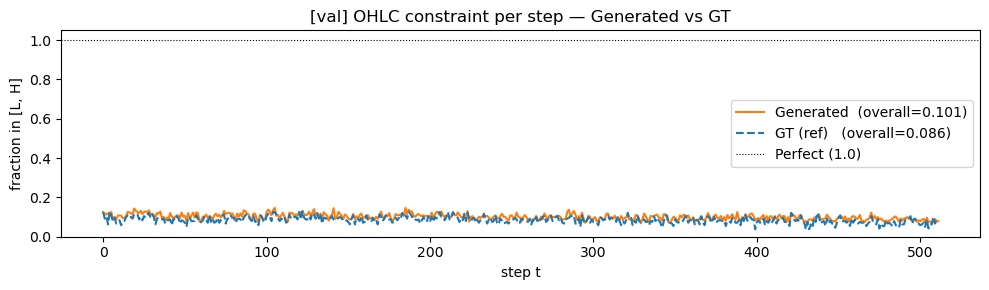

In [100]:
# ── Generated Close constraint ────────────────────────────────────────────────
above_low  = all_gen_close >= all_gt_low
below_high = all_gen_close <= all_gt_high
in_band    = above_low & below_high

step_rate   = in_band.mean(axis=0)
fully_valid = in_band.all(axis=1).mean()
stepwise    = in_band.mean()

# ── Ground-truth Close constraint (baseline) ──────────────────────────────────
gt_above_low  = all_gt_close >= all_gt_low
gt_below_high = all_gt_close <= all_gt_high
gt_in_band    = gt_above_low & gt_below_high

gt_step_rate   = gt_in_band.mean(axis=0)
gt_fully_valid = gt_in_band.all(axis=1).mean()
gt_stepwise    = gt_in_band.mean()

print("=" * 55)
print("  OHLC CONSTRAINT  L ≤ Close ≤ H")
print("=" * 55)
print(f"{'Metric':<35} {'Generated':>10} {'GT (ref)':>10}")
print("-" * 55)
print(f"{'Step-wise satisfaction rate':<35} {stepwise:>10.4f} {gt_stepwise:>10.4f}")
print(f"{'Fully valid samples':<35} {fully_valid:>10.4f} {gt_fully_valid:>10.4f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(steps, step_rate,    color="tab:orange", lw=1.5, label=f"Generated  (overall={stepwise:.3f})")
ax.plot(steps, gt_step_rate, color="tab:blue",   lw=1.5, label=f"GT (ref)   (overall={gt_stepwise:.3f})", ls="--")
ax.axhline(1.0, color="black", lw=0.8, ls=":", label="Perfect (1.0)")
ax.set_ylim(0, 1.05)
ax.set_xlabel("step t")
ax.set_ylabel("fraction in [L, H]")
ax.set_title(f"[{ANALYSIS_SPLIT}] OHLC constraint per step — Generated vs GT")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 5. Marginal distribution of Close values
We are testing:
* Marginal close distribution overall
* QQ plots for quantile values
* ECDF (Empirical CDF), or F(x)=(y<=x) / N, where y is the number of values smaller or equal to x and N is the total number of observations.

KS statistic = 0.0302  |  p-value = 0.0000e+00
Wasserstein-1 distance = 0.050338


,count,mean,std,min,q01,q05,q25,q50,q75,q95,q99,max,skewness,excess_kurtosis
label,,,,,,,,,,,,,,
Generated Close,1223680,0.00146,0.77435,-14.40247,-2.08301,-1.17376,-0.38643,-0.01911,0.38798,1.19503,2.11096,11.58087,-0.26401,9.72398
Ground-truth Close,1223680,-0.00236,0.86563,-13.83369,-2.33045,-1.28712,-0.41770,-0.02163,0.41248,1.30354,2.37229,10.48888,-0.40687,13.96397


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\1584418208.py:42: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 3, figsize=(15, 4))


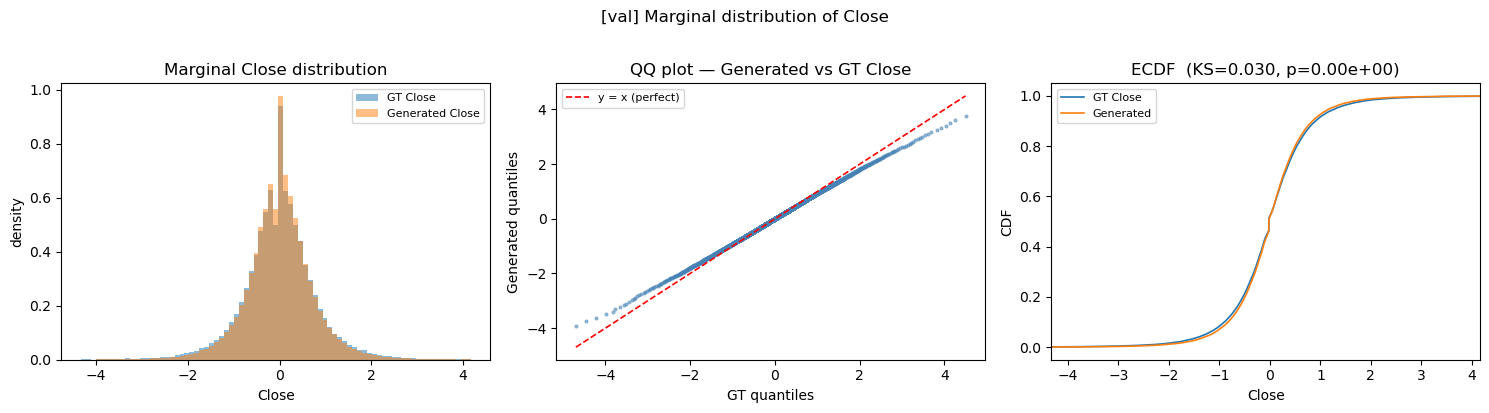

In [101]:
gen_flat = all_gen_close.ravel()
gt_flat  = all_gt_close.ravel()

ks_stat, ks_p = scipy_stats.ks_2samp(gen_flat, gt_flat)
w1_dist = scipy_stats.wasserstein_distance(gen_flat, gt_flat)


def moments(x, label):
    return {
        "label"           : label,
        "count"           : len(x),
        "mean"            : np.mean(x),
        "std"             : np.std(x),
        "min"             : np.min(x),
        "q01"             : np.quantile(x, 0.01),
        "q05"             : np.quantile(x, 0.05),
        "q25"             : np.quantile(x, 0.25),
        "q50"             : np.quantile(x, 0.50),
        "q75"             : np.quantile(x, 0.75),
        "q95"             : np.quantile(x, 0.95),
        "q99"             : np.quantile(x, 0.99),
        "max"             : np.max(x),
        "skewness"        : scipy_stats.skew(x),
        "excess_kurtosis" : scipy_stats.kurtosis(x, fisher=True),
    }

df_moments = pd.DataFrame([
    moments(gen_flat, "Generated Close"),
    moments(gt_flat,  "Ground-truth Close"),
]).set_index("label").round(5)

print(f"KS statistic = {ks_stat:.4f}  |  p-value = {ks_p:.4e}")
print(f"Wasserstein-1 distance = {w1_dist:.6f}")

display(df_moments)

combined = np.concatenate([gen_flat, gt_flat])
lo, hi   = np.quantile(combined, [0.001, 0.999])
bins     = np.linspace(lo, hi, 80)
probs    = np.linspace(0.001, 0.999, min(len(gen_flat), 5_000))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(gt_flat,  bins=bins, density=True, alpha=0.5, label="GT Close",        color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.5, label="Generated Close", color="tab:orange")
ax.set_title("Marginal Close distribution")
ax.set_xlabel("Close"); ax.set_ylabel("density"); ax.legend(fontsize=8)

ax = axes[1]
q_gt  = np.quantile(gt_flat,  probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_gt, q_gen, s=4, alpha=0.5, color="steelblue")
lims = [min(q_gt.min(), q_gen.min()), max(q_gt.max(), q_gen.max())]
ax.plot(lims, lims, "r--", lw=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — Generated vs GT Close")
ax.set_xlabel("GT quantiles"); ax.set_ylabel("Generated quantiles"); ax.legend(fontsize=8)

ax = axes[2]
for vals, label, color in [(gt_flat, "GT Close", "tab:blue"), (gen_flat, "Generated", "tab:orange")]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, lw=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF  (KS={ks_stat:.3f}, p={ks_p:.2e})")
ax.set_xlabel("Close"); ax.set_ylabel("CDF"); ax.legend(fontsize=8)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Marginal distribution of Close", y=1.02)
plt.tight_layout()
display(fig)
plt.savefig(f"../images/final/edm/marginal_distribution_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

In [102]:
# KS on the central 98 % (exclude bottom/top 1 % of the combined distribution)
combined_q01, combined_q99 = np.quantile(np.concatenate([gen_flat, gt_flat]), [0.01, 0.99])
gen_trim = gen_flat[(gen_flat >= combined_q01) & (gen_flat <= combined_q99)]
gt_trim  = gt_flat [(gt_flat  >= combined_q01) & (gt_flat  <= combined_q99)]
ks_trim_stat, ks_trim_p = scipy_stats.ks_2samp(gen_trim, gt_trim)
print(f"KS statistic (trimmed, central 98%) = {ks_trim_stat:.4f}  |  p-value = {ks_trim_p:.4e}")


KS statistic (trimmed, central 98%) = 0.0308  |  p-value = 0.0000e+00


## 6. Close increments distribution and ACF

Increment KS = 0.0160  p = 4.6579e-136
Wasserstein-1 distance = 0.072474


,count,mean,std,min,q01,q05,q25,q50,q75,q95,q99,max,skewness,excess_kurtosis
label,,,,,,,,,,,,,,
Generated ΔClose,1221290,0.00033,1.09198,-15.04435,-2.91789,-1.66645,-0.56330,-0.00198,0.55633,1.68538,2.97687,17.442850,0.15630,7.09797
GT ΔClose,1221290,0.00034,1.21971,-15.56292,-3.29341,-1.82565,-0.60676,-0.00167,0.59652,1.85286,3.35318,20.413019,0.18932,10.00035


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\3776919369.py:32: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(13, 7))


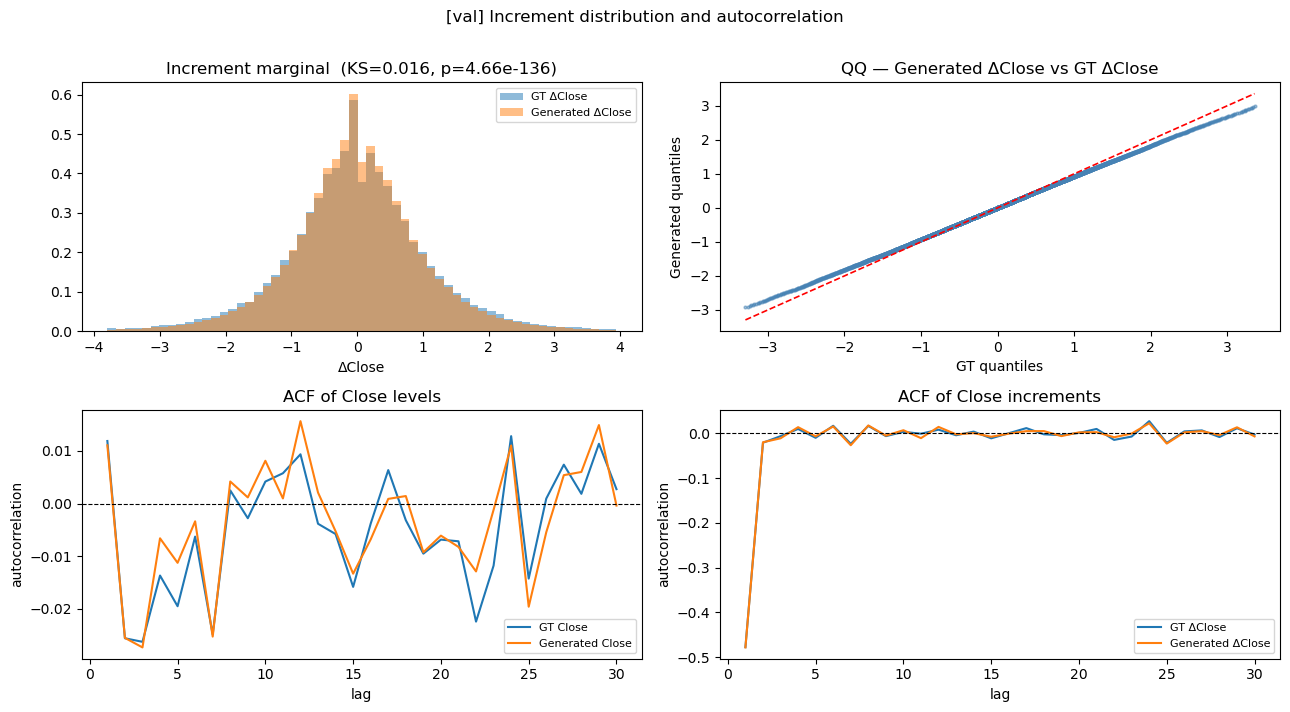

In [103]:
gen_inc = np.diff(all_gen_close, axis=1).ravel()
gt_inc  = np.diff(all_gt_close,  axis=1).ravel()

ks_inc, ks_p_inc = scipy_stats.ks_2samp(gen_inc, gt_inc)
print(f"Increment KS = {ks_inc:.4f}  p = {ks_p_inc:.4e}")

w1_dist_inc = scipy_stats.wasserstein_distance(gen_inc, gt_inc)
print(f"Wasserstein-1 distance = {w1_dist_inc:.6f}")



df_inc = pd.DataFrame([
    moments(gen_inc, "Generated ΔClose"),
    moments(gt_inc,  "GT ΔClose"),
]).set_index("label").round(5)
display(df_inc)

N_ACF    = min(50, n_windows)
LAGS     = min(30, seq_len // 2)
lag_axis = np.arange(1, LAGS + 1)

def mean_acf(paths, lags, use_diff=False):
    acfs = []
    for p in paths[:N_ACF]:
        x = np.diff(p) if use_diff else p
        acfs.append(acf(x, nlags=lags, fft=True)[1:])
    return np.mean(acfs, axis=0)

# For ACF we pick one sample per window (sample 0) to avoid repetition artefacts
gen_paths_s0 = gen_3d[:, 0, :]   # (n_windows, seq_len)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

lo_i, hi_i = np.quantile(np.concatenate([gen_inc, gt_inc]), [0.005, 0.995])
bins_i = np.linspace(lo_i, hi_i, 60)
axes[0, 0].hist(gt_inc,  bins=bins_i, density=True, alpha=0.5, label="GT ΔClose",        color="tab:blue")
axes[0, 0].hist(gen_inc, bins=bins_i, density=True, alpha=0.5, label="Generated ΔClose", color="tab:orange")
axes[0, 0].set_title(f"Increment marginal  (KS={ks_inc:.3f}, p={ks_p_inc:.2e})")
axes[0, 0].set_xlabel("ΔClose"); axes[0, 0].legend(fontsize=8)

probs_i = np.linspace(0.01, 0.99, min(len(gen_inc), 5_000))
q_gt_i  = np.quantile(gt_inc,  probs_i)
q_gen_i = np.quantile(gen_inc, probs_i)
axes[0, 1].scatter(q_gt_i, q_gen_i, s=4, alpha=0.5, color="steelblue")
lims_i = [min(q_gt_i.min(), q_gen_i.min()), max(q_gt_i.max(), q_gen_i.max())]
axes[0, 1].plot(lims_i, lims_i, "r--", lw=1.2)
axes[0, 1].set_title("QQ — Generated ΔClose vs GT ΔClose")
axes[0, 1].set_xlabel("GT quantiles"); axes[0, 1].set_ylabel("Generated quantiles")

axes[1, 0].plot(lag_axis, mean_acf(gt_close,      LAGS, use_diff=False), label="GT Close",        color="tab:blue")
axes[1, 0].plot(lag_axis, mean_acf(gen_paths_s0,  LAGS, use_diff=False), label="Generated Close", color="tab:orange")
axes[1, 0].axhline(0, color="black", lw=0.8, ls="--")
axes[1, 0].set_title("ACF of Close levels")
axes[1, 0].set_xlabel("lag"); axes[1, 0].set_ylabel("autocorrelation"); axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(lag_axis, mean_acf(gt_close,      LAGS, use_diff=True), label="GT ΔClose",        color="tab:blue")
axes[1, 1].plot(lag_axis, mean_acf(gen_paths_s0,  LAGS, use_diff=True), label="Generated ΔClose", color="tab:orange")
axes[1, 1].axhline(0, color="black", lw=0.8, ls="--")
axes[1, 1].set_title("ACF of Close increments")
axes[1, 1].set_xlabel("lag"); axes[1, 1].set_ylabel("autocorrelation"); axes[1, 1].legend(fontsize=8)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Increment distribution and autocorrelation", y=1.01)
plt.tight_layout()
display(fig)
plt.savefig(f"../images/final/edm/marginal_distribution_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

## 7. Per-step conditional mean ± std

At each timestep: generated sample mean vs GT Close, with ±1 std band.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\1689782758.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, N_SHOW2, figsize=(5 * N_SHOW2, 4), sharey=False)


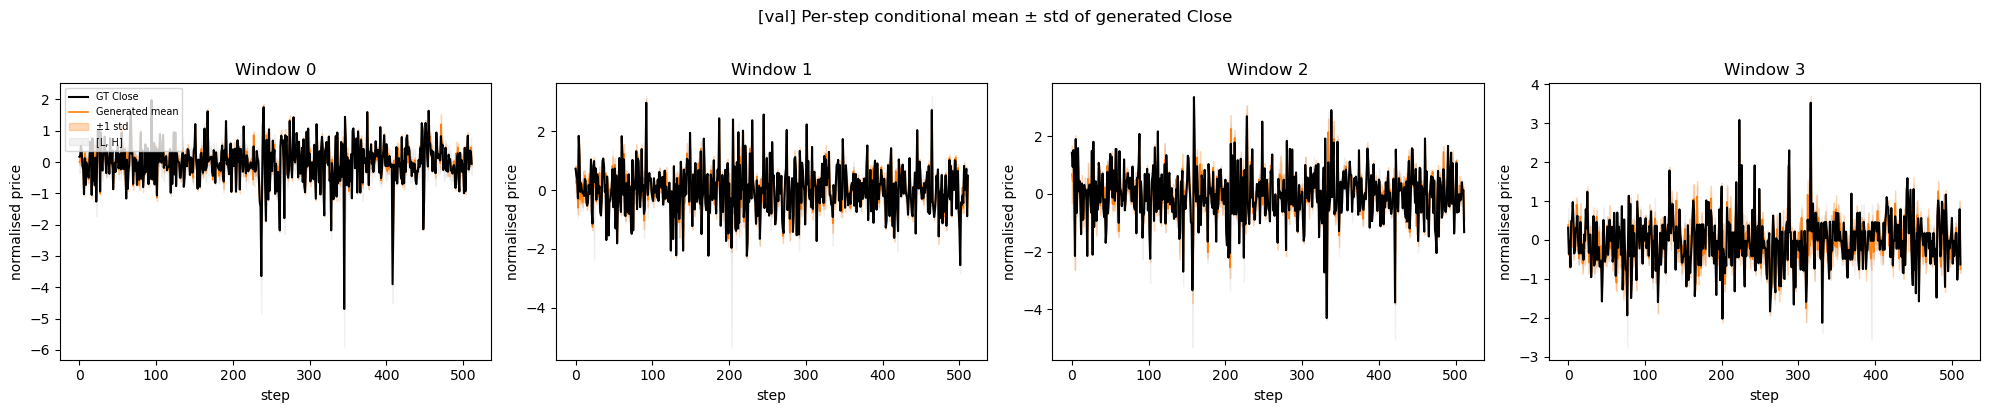

Mean absolute error  (generated mean vs GT): 0.20204
RMSE                 (generated mean vs GT): 0.30896
Mean generated std   (residual uncertainty): 0.20240


In [104]:
gen_mean = gen_3d.mean(axis=1)   # (n_windows, seq_len)
gen_std  = gen_3d.std(axis=1)    # (n_windows, seq_len)

N_SHOW2 = min(n_windows, 4)
fig, axes = plt.subplots(1, N_SHOW2, figsize=(5 * N_SHOW2, 4), sharey=False)
if N_SHOW2 == 1:
    axes = [axes]

for col, w in enumerate(range(N_SHOW2)):
    ax = axes[col]
    ax.plot(steps, gt_close[w],  color="black",      lw=1.5, label="GT Close",       zorder=3)
    ax.plot(steps, gen_mean[w],  color="tab:orange", lw=1.2, label="Generated mean", zorder=2)
    ax.fill_between(
        steps,
        gen_mean[w] - gen_std[w],
        gen_mean[w] + gen_std[w],
        alpha=0.3, color="tab:orange", label="±1 std"
    )
    ax.fill_between(steps, gt_low[w], gt_high[w], alpha=0.10, color="gray", label="[L, H]")
    ax.set_title(f"Window {window_ids[w]}")
    ax.set_xlabel("step")
    ax.set_ylabel("normalised price")

axes[0].legend(fontsize=7, loc="upper left")
plt.suptitle(f"[{ANALYSIS_SPLIT}] Per-step conditional mean ± std of generated Close", y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

mae  = np.abs(gen_mean - gt_close).mean()
rmse = np.sqrt(((gen_mean - gt_close) ** 2).mean())
print(f"Mean absolute error  (generated mean vs GT): {mae:.5f}")
print(f"RMSE                 (generated mean vs GT): {rmse:.5f}")
print(f"Mean generated std   (residual uncertainty): {gen_std.mean():.5f}")

# Marginal on full dataset

In [105]:
# # ── USER INPUTS ──────────────────────────────────────────────────────────────
# TRAINING_DATASET         = "../data/SNP500_individual_normalized_replication_copy"
# # Path to the folder of training CSVs (or a single CSV file).
# # Each CSV must have at least a 'close' column with log-return values.

# TRAINING_DATA_NORMALIZED = False
# # True  → values in TRAINING_DATASET are already z-score-normalised
# #          (same scale as gen_flat / gt_flat in this notebook).
# # False → values are raw log-returns; the cell normalises them automatically
# #          using the column statistics found in STATS_FILE (cell 2).
# # ─────────────────────────────────────────────────────────────────────────────

# import glob as _glob

# # ── 13.1  Load training close sequences ──────────────────────────────────────
# def _load_close_seqs(path):
#     if os.path.isfile(path):
#         files = [path]
#     elif os.path.isdir(path):
#         files = sorted(_glob.glob(os.path.join(path, "*.csv")))
#         if not files:
#             raise FileNotFoundError(f"No .csv files found in: {path}")
#     else:
#         raise FileNotFoundError(f"TRAINING_DATASET path not found: {path}")

#     seqs = []
#     for fpath in files:
#         df = pd.read_csv(fpath)
#         df.columns = df.columns.str.strip().str.lower()
#         if "close" not in df.columns:
#             raise ValueError(
#                 f"No 'close' column in {os.path.basename(fpath)}. "
#                 f"Available: {list(df.columns)}"
#             )
#         seqs.append(df["close"].dropna().to_numpy(dtype=float))
#     return seqs


# train_seqs_raw = _load_close_seqs(TRAINING_DATASET)

# if TRAINING_DATA_NORMALIZED:
#     train_seqs = train_seqs_raw
# else:
#     _stats_df = pd.read_csv(STATS_FILE, header=0, index_col=0)
#     _stats_df.columns = _stats_df.columns.str.strip()
#     _stats_df.index   = _stats_df.index.str.strip().str.lower()
#     _tr_mu  = float(_stats_df.loc["close", "mean"])
#     _tr_sig = float(_stats_df.loc["close", "std"])
#     train_seqs = [(s - _tr_mu) / _tr_sig for s in train_seqs_raw]

# train_flat = np.concatenate(train_seqs)
# # increments per sequence to avoid cross-ticker jumps
# train_inc  = np.concatenate([np.diff(s) for s in train_seqs if len(s) > 1])

# print(f"Training dataset : {len(train_seqs):>5} files  |  "
#       f"{len(train_flat):>10,} values  |  {len(train_inc):>10,} increments")
# print(f"Generated        :         —      |  "
#       f"{len(gen_flat):>10,} values  |  {len(gen_inc):>10,} increments")

# # ── 13.2  Summary statistics ──────────────────────────────────────────────────
# print("\n=== Marginal Close — moments ===")
# df_moments_train = pd.DataFrame([
#     moments(gen_flat,   "Generated Close"),
#     moments(gt_flat,    "GT Close (windows)"),
#     moments(train_flat, "Training dataset Close"),
# ]).set_index("label").round(5)
# display(df_moments_train)

# print("\n=== Increment ΔClose — moments ===")
# df_inc_train = pd.DataFrame([
#     moments(gen_inc,   "Generated ΔClose"),
#     moments(gt_inc,    "GT ΔClose (windows)"),
#     moments(train_inc, "Training dataset ΔClose"),
# ]).set_index("label").round(5)
# display(df_inc_train)

# # ── 13.3  KS & Wasserstein-1 (generated vs training) ─────────────────────────
# ks_marg,  p_marg  = scipy_stats.ks_2samp(gen_flat, train_flat)
# w1_marg            = scipy_stats.wasserstein_distance(gen_flat,  train_flat)
# ks_inc_t, p_inc_t  = scipy_stats.ks_2samp(gen_inc,  train_inc)
# w1_inc_t           = scipy_stats.wasserstein_distance(gen_inc,   train_inc)

# print("\n--- Generated vs Full Training ---")
# print(f"Marginal   : KS = {ks_marg:.4f}   p = {p_marg:.2e}   W₁ = {w1_marg:.6f}")
# print(f"Increments : KS = {ks_inc_t:.4f}   p = {p_inc_t:.2e}   W₁ = {w1_inc_t:.6f}")

# # ── 13.4  Plots ───────────────────────────────────────────────────────────────
# _PAL  = {"gen": "tab:orange", "gt": "tab:blue", "train": "tab:green"}
# _N_QQ = 5_000

# def _ecdf_xy(x, lo, hi):
#     s = np.sort(x[(x >= lo) & (x <= hi)])
#     return s, np.arange(1, len(s) + 1) / len(s)

# fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# # ── Row 0: marginal ───────────────────────────────────────────────────────────
# lo_m, hi_m = np.quantile(np.concatenate([gen_flat, train_flat]), [0.0005, 0.9995])
# bins_m     = np.linspace(lo_m, hi_m, 80)
# probs_m    = np.linspace(0.001, 0.999, _N_QQ)

# ax = axes[0, 0]
# ax.hist(train_flat, bins=bins_m, density=True, alpha=0.55,
#         label="Training",  color=_PAL["train"])
# ax.hist(gen_flat,   bins=bins_m, density=True, alpha=0.55,
#         label="Generated", color=_PAL["gen"])
# ax.set_title(f"Marginal Close  (KS={ks_marg:.3f}, W₁={w1_marg:.4f})")
# ax.set_xlabel("Close log-return"); ax.set_ylabel("density"); ax.legend(fontsize=8)

# ax = axes[0, 1]
# q_tr_m = np.quantile(train_flat, probs_m)
# q_gn_m = np.quantile(gen_flat,   probs_m)
# ax.scatter(q_tr_m, q_gn_m, s=4, alpha=0.5, color="steelblue")
# lim_m = [min(q_tr_m.min(), q_gn_m.min()), max(q_tr_m.max(), q_gn_m.max())]
# ax.plot(lim_m, lim_m, "r--", lw=1.2, label="y = x (perfect)")
# ax.set_title("QQ — Generated vs Training Close")
# ax.set_xlabel("Training quantiles"); ax.set_ylabel("Generated quantiles")
# ax.legend(fontsize=8)

# ax = axes[0, 2]
# for vals, lbl, col, ls in [
#     (train_flat, "Training",     _PAL["train"], "-"),
#     (gen_flat,   "Generated",    _PAL["gen"],   "-"),
#     (gt_flat,    "GT (windows)", _PAL["gt"],    "--"),
# ]:
#     xv, yv = _ecdf_xy(vals, lo_m, hi_m)
#     ax.plot(xv, yv, lw=1.2, label=lbl, color=col, ls=ls)
# ax.set_title("ECDF — Close")
# ax.set_xlabel("Close log-return"); ax.set_ylabel("CDF"); ax.legend(fontsize=8)

# # ── Row 1: increments ─────────────────────────────────────────────────────────
# lo_i, hi_i = np.quantile(np.concatenate([gen_inc, train_inc]), [0.001, 0.999])
# bins_i     = np.linspace(lo_i, hi_i, 80)
# probs_i    = np.linspace(0.001, 0.999, _N_QQ)

# ax = axes[1, 0]
# ax.hist(train_inc, bins=bins_i, density=True, alpha=0.55,
#         label="Training ΔClose",  color=_PAL["train"])
# ax.hist(gen_inc,   bins=bins_i, density=True, alpha=0.55,
#         label="Generated ΔClose", color=_PAL["gen"])
# ax.set_title(f"Increment ΔClose  (KS={ks_inc_t:.3f}, W₁={w1_inc_t:.4f})")
# ax.set_xlabel("ΔClose"); ax.set_ylabel("density"); ax.legend(fontsize=8)

# ax = axes[1, 1]
# q_tr_i = np.quantile(train_inc, probs_i)
# q_gn_i = np.quantile(gen_inc,   probs_i)
# ax.scatter(q_tr_i, q_gn_i, s=4, alpha=0.5, color="steelblue")
# lim_i = [min(q_tr_i.min(), q_gn_i.min()), max(q_tr_i.max(), q_gn_i.max())]
# ax.plot(lim_i, lim_i, "r--", lw=1.2, label="y = x (perfect)")
# ax.set_title("QQ — Generated vs Training ΔClose")
# ax.set_xlabel("Training quantiles"); ax.set_ylabel("Generated quantiles")
# ax.legend(fontsize=8)

# ax = axes[1, 2]
# for vals, lbl, col, ls in [
#     (train_inc, "Training ΔClose",     _PAL["train"], "-"),
#     (gen_inc,   "Generated ΔClose",    _PAL["gen"],   "-"),
#     (gt_inc,    "GT ΔClose (windows)", _PAL["gt"],    "--"),
# ]:
#     xv, yv = _ecdf_xy(vals, lo_i, hi_i)
#     ax.plot(xv, yv, lw=1.2, label=lbl, color=col, ls=ls)
# ax.set_title("ECDF — ΔClose")
# ax.set_xlabel("ΔClose"); ax.set_ylabel("CDF"); ax.legend(fontsize=8)

# plt.suptitle(
#     f"[{ANALYSIS_SPLIT}]  Generated vs Full Training Dataset\n"
#     f"Marginal: KS={ks_marg:.3f}  W₁={w1_marg:.4f}  |  "
#     f"Increment: KS={ks_inc_t:.3f}  W₁={w1_inc_t:.4f}",
#     y=1.02, fontsize=12,
# )
# plt.tight_layout()
# display(fig)
# plt.savefig(
#     f"../images/final/edm/vs_training_marginals_{appendix}.png",
#     dpi=300, bbox_inches="tight",
# )
# plt.close(fig)


## 8. Train vs Val comparison (requires SPLIT="both")

Side-by-side summary statistics for train and validation splits.

In [106]:
if len(parsed) < 2:
    print("Set SPLIT='both' at the top to enable train/val comparison.")
else:
    rows = []
    for sp, (g3d, gtc, gto, gth, gtl, wids) in parsed.items():
        nw, ns, sl = g3d.shape
        gen_all = g3d.reshape(nw * ns, sl)
        gt_all  = np.repeat(gtc, ns, axis=0)
        ks, ks_p  = scipy_stats.ks_2samp(gen_all.ravel(), gt_all.ravel())
        gm = g3d.mean(axis=1)
        mae  = np.abs(gm - gtc).mean()
        rmse = np.sqrt(((gm - gtc) ** 2).mean())
        in_b = ((gen_all >= np.repeat(gtl, ns, axis=0)) &
                (gen_all <= np.repeat(gth, ns, axis=0))).mean()
        rows.append({
            "split"          : sp,
            "n_windows"      : nw,
            "n_samples"      : ns,
            "KS stat"        : round(ks, 4),
            "KS p-value"     : f"{ks_p:.2e}",
            "MAE (mean vs GT)": round(mae, 5),
            "RMSE"           : round(rmse, 5),
            "OHLC step rate" : round(float(in_b), 4),
        })
    display(pd.DataFrame(rows).set_index("split"))

Set SPLIT='both' at the top to enable train/val comparison.


# 9. FTS metrics

In [107]:
import sys
sys.path.insert(0, "..")
import replication.stylized_facts as sf
from pathlib import Path

output_dir = Path("../images/final/edm/stylized_facts_ohlc_conditional")
output_dir.mkdir(exist_ok=True, parents=True)
print(f"Saving stylized facts plots to: {output_dir.resolve()}")


Saving stylized facts plots to: C:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\THESIS\Master-Thesis\images\final\edm\stylized_facts_ohlc_conditional


In [108]:
MAX_STEM_LEN = 40
if len(CHECKPOINT_STEM) > MAX_STEM_LEN:
    CHECKPOINT_STEM = CHECKPOINT_STEM[:MAX_STEM_LEN] + CHECKPOINT_STEM[-14:]
print(CHECKPOINT_STEM)

EDM_REPLICATION_CLOS_ep-500_step-44500_s0260601_092603


In [109]:
print(gt_close.shape, gt_close.shape[0]*gt_close.shape[1])
print(all_gen_close.shape, all_gen_close.shape[0]*all_gen_close.shape[1])

(239, 512) 122368
(2390, 512) 1223680


In [110]:
# ── Flat 1-D arrays for sf.distribution ──────────────────────────────────────
# gt_close  : (n_windows, seq_len) → ravel to 1-D
# all_gen_close : (n_windows * n_samples, seq_len) — already defined above
gt_close_pooled = gt_close.ravel()        # shape: (n_windows * seq_len,)
gen_paths_arr   = all_gen_close.ravel()   # shape: (n_windows * n_samples * seq_len,)

print(gt_close_pooled.shape)
print(gen_paths_arr.shape)

# ── Object arrays of individual paths for sf.acf / sf.leverage_effect ────────
gt_close_obj = np.empty(n_windows, dtype=object)
for i, p in enumerate(gt_close):
    gt_close_obj[i] = p                   # each element: (seq_len,) GT Close window

gen_paths_obj = np.empty(len(all_gen_close), dtype=object)
for i, p in enumerate(all_gen_close):
    gen_paths_obj[i] = p                  # each element: (seq_len,) generated path

print(gt_close_obj.shape, gt_close_obj[0].shape)
print(gen_paths_obj.shape, gen_paths_obj[0].shape)

(122368,)
(1223680,)
(239,) (512,)
(2390,) (512,)


In [111]:
compute_graph_overlap = True

In [112]:
gt_dist_x, gt_dist_y = sf.distribution(
    gt_close_pooled,
    file_name=str(output_dir / f"gt_distribution_{CHECKPOINT_STEM}"),
    scale="log", multiple=False, normalize=True, granuality=100,
)

gen_dist_x, gen_dist_y = sf.distribution(
    gen_paths_arr,
    file_name=str(output_dir / f"generated_distribution_{CHECKPOINT_STEM}"),
    scale="log", multiple=False, normalize=True, granuality=100,
)


c:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\THESIS\Master-Thesis\notebooks\..\replication\visualize.py:94: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(dpi=150)
c:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\THESIS\Master-Thesis\notebooks\..\replication\visualize.py:103: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(dpi=150)


In [113]:
gt_acf_res = sf.acf(
    gt_close_obj,
    file_name=str(output_dir / f"gt_volatility_clustering_{CHECKPOINT_STEM}"),
    for_abs=True, multiple=True, fit=False, scale="log",
    max_lag=min(1000, seq_len // 2),
)

gen_acf_res = sf.acf(
    gen_paths_obj,
    file_name=str(output_dir / f"generated_volatility_clustering_{CHECKPOINT_STEM}"),
    for_abs=True, multiple=True, fit=False, scale="log",
    max_lag=min(1000, seq_len // 2),
)


c:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\THESIS\Master-Thesis\notebooks\..\replication\visualize.py:114: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(dpi=150)


In [114]:
gt_levs = sf.leverage_effect(
    gt_close_obj,
    file_name=str(output_dir / f"gt_leverage_effect_{CHECKPOINT_STEM}"),
    multiple=True, min_lag=1, max_lag=min(100, seq_len // 2),
)

gen_levs = sf.leverage_effect(
    gen_paths_obj,
    file_name=str(output_dir / f"generated_leverage_effect_{CHECKPOINT_STEM}"),
    multiple=True, min_lag=1, max_lag=min(100, seq_len // 2),
)


c:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\THESIS\Master-Thesis\notebooks\..\replication\visualize.py:62: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(dpi=150)


In [115]:
# import powerlaw

run_fast_powerlaw = True
# if not run_fast_powerlaw:
#     def fit_powerlaw(returns, max_sample=10000, seed=42):
#         x = np.abs(np.asarray(returns, dtype=float))
#         x = x[np.isfinite(x) & (x > 0)]

#         if len(x) > max_sample:
#             rng_local = np.random.default_rng(seed)
#             x = rng_local.choice(x, size=max_sample, replace=False)

#         f = powerlaw.Fit(x, discrete=False, verbose=True,
#                         parameter_ranges={"alpha": [1.5, 10.0]})

#         x_tail = x[x >= f.power_law.xmin]
#         alpha_mle = 1 + len(x_tail) / np.sum(np.log(x_tail / f.power_law.xmin))

#         return {
#             "alpha"    : f.power_law.alpha,
#             "alpha_mle": alpha_mle,
#             "xmin"     : f.power_law.xmin,
#             "ks"       : f.power_law.D,
#             "n_total"  : len(x),
#             "n_tail"   : len(x_tail),
#         }

#     # gt_close_pooled and gen_paths_arr are the flat 1-D arrays built in the previous block.
#     # They are already log-returns, so concatenation directly gives the return sample —
#     # identical to np.concatenate(list(paths)) in Training_vs_Generated_Analysis.
#     for arr, label in [(gt_close_pooled, "GT Close"), (gen_paths_arr, "Generated Close")]:
#         r = fit_powerlaw(arr)
#         print(f"{label}")
#         print(f"  alpha (powerlaw) : {r['alpha']:.4f}")
#         print(f"  alpha_mle        : {r['alpha_mle']:.4f}")
#         print(f"  xmin             : {r['xmin']:.6f}")
#         print(f"  KS distance      : {r['ks']:.4f}")
#         print(f"  n_total          : {r['n_total']:,}")
#         print(f"  n_tail           : {r['n_tail']:,}")
#         print()


### Faster Power-Law Fitting

In [ ]:
import numpy as np

def fit_powerlaw_fast(returns, max_sample=100000, seed=42):
    x = np.abs(np.asarray(returns, dtype=float))
    x = x[np.isfinite(x) & (x > 0)]
    n_total = len(x)

    if n_total > max_sample:
        x = np.random.default_rng(seed).choice(x, size=max_sample, replace=False)

    x = np.sort(x)
    n = len(x)
    log_x = np.log(x)

    # ── Hill estimator for every candidate xmin = x[i], all at once ──────────
    # alpha[i] = 1 + (n-i) / sum_{j>=i} log(x[j] / x[i])
    #
    # rev_cumlog[i] = sum(log_x[i:])  via a single reverse cumsum — O(n)
    rev_cumlog  = np.cumsum(log_x[::-1])[::-1]
    n_tail_arr  = np.arange(n, 0, -1, dtype=np.float64)   # n - i per candidate
    sum_log_r   = rev_cumlog - n_tail_arr * log_x          # sum log(x[j]/x[i]) ∀j≥i
    valid       = sum_log_r > 1e-12
    safe_denom = np.where(valid, sum_log_r, 1.0)          # replace invalid zeros
    alpha_arr  = np.where(valid, 1.0 + n_tail_arr / safe_denom, np.inf)

    # ── KS statistic per candidate — vectorised inner body ────────────────────
    ks_arr = np.full(n, np.inf)
    for i in range(n - 1):
        if not valid[i]:
            continue
        m      = n - i
        a      = alpha_arr[i]
        # Pareto CDF:       F(t) = 1 - (xmin/t)^(alpha-1)
        cdf_th = 1.0 - (x[i] / x[i:]) ** (a - 1.0)
        # Empirical CDF at each sorted tail point
        cdf_em = np.arange(1, m + 1, dtype=np.float64) / m
        ks_arr[i] = np.max(np.abs(cdf_em - cdf_th))

    best = int(np.argmin(ks_arr))
    return {
        "alpha"    : float(alpha_arr[best]),
        "alpha_mle": float(alpha_arr[best]),   # identical to alpha — Hill IS MLE
        "xmin"     : float(x[best]),
        "ks"       : float(ks_arr[best]),
        "n_total"  : len(x),
        "n_tail"   : n - best,
    }

for arr, label in [(gt_close_pooled, "GT Close"), (gen_paths_arr, "Generated Close")]:
        r = fit_powerlaw_fast(arr)
        print(f"{label}")
        print(f"  alpha (powerlaw) : {r['alpha']:.4f}")
        print(f"  alpha_mle        : {r['alpha_mle']:.4f}")
        print(f"  xmin             : {r['xmin']:.6f}")
        print(f"  KS distance      : {r['ks']:.4f}")
        print(f"  n_total          : {r['n_total']:,}")
        print(f"  n_tail           : {r['n_tail']:,}")
        print()

GT Close
  alpha (powerlaw) : 4.5470
  alpha_mle        : 4.5470
  xmin             : 3.533091
  KS distance      : 0.0193
  n_total          : 100,000
  n_tail           : 480



### Compute graph overlap

In [ ]:
if compute_graph_overlap:
    for sign, mask_fn, suffix in [(1, lambda x: x > 0, "pos"), (-1, lambda x: x < 0, "neg")]:
        m_gt  = mask_fn(gt_dist_x)
        m_gen = mask_fn(gen_dist_x)
        plt.figure(dpi=150)
        plt.plot(sign * gt_dist_x[m_gt],   gt_dist_y[m_gt],  '.', color="tab:blue",   label="GT")
        plt.plot(sign * gen_dist_x[m_gen],  gen_dist_y[m_gen],'.', color="tab:orange", label="Generated")
        plt.xscale('log'); plt.yscale('log')
        plt.xlabel('Normalized Scale in $\sigma$', fontsize=20)
        plt.ylabel('Probability Density Function $P(r)$', fontsize=20)
        plt.legend(fontsize=14)
        plt.savefig(str(output_dir / f"overlap_distribution_{CHECKPOINT_STEM}_{suffix}_log.png"), transparent=True)
        plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\3792392440.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Normalized Scale in $\sigma$', fontsize=20)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\3792392440.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
if compute_graph_overlap:
    lags = np.linspace(1, gt_acf_res.size, gt_acf_res.size)
    plt.figure(dpi=150)
    plt.plot(lags, gt_acf_res,  '.', color="tab:blue",   label="GT")
    plt.plot(lags, gen_acf_res, '.', color="tab:orange", label="Generated")
    plt.ylim(1e-5, 1.)
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel('lag $k$', fontsize=20)
    plt.ylabel('Auto-correlation', fontsize=20)
    plt.legend(fontsize=14)
    plt.savefig(str(output_dir / f"overlap_volatility_clustering_{CHECKPOINT_STEM}.png"), transparent=True)
    plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\1629015660.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
if compute_graph_overlap:
    plt.figure(dpi=150)
    plt.plot(range(1, min(100, seq_len // 2)), gt_levs,  color="tab:blue",   label="GT")
    plt.plot(range(1, min(100, seq_len // 2)), gen_levs, color="tab:orange", label="Generated")
    plt.axhline()
    plt.xlabel(r'$t$', fontsize=20)
    plt.ylabel(r'$L(t)$', fontsize=20)
    plt.legend(fontsize=14)
    plt.savefig(str(output_dir / f"overlap_leverage_effect_{CHECKPOINT_STEM}.png"), transparent=True)
    plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14244\3103583001.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Interpretation guide

| Test | Passing (overfit / well-conditioned) | Failing |
|------|--------------------------------------|---------|
| **Sample paths** (§3) | Generated Close tracks GT inside [L,H] | Paths wander outside [L,H] or uncorrelated with GT |
| **OHLC constraint** (§4) | Step-wise rate > 0.90 | Rate < 0.5 → model ignores OHL context |
| **Marginal KS** (§5) | KS p > 0.05; QQ on diagonal | S-curve in QQ (wrong tail shape) |
| **Increment KS** (§6) | KS p > 0.05; similar std | Generated std much larger → noise not removed |
| **Level ACF** (§6) | Generated ACF tracks GT shape | Flat or too fast decay → wrong temporal structure |
| **Increment ACF** (§6) | Both near 0 at all lags | Positive lags → spurious momentum |
| **Per-step mean** (§7) | MAE near 0; small residual std | Large MAE → bad conditioning; large std → excess uncertainty |

# Unnormalization of close values

In [ ]:
# ── 12.1  Load column-level mean / std ────────────────────────────────────────
stats_df = pd.read_csv(STATS_FILE, header=0, index_col=0)
stats_df.columns = ["mean", "std"]
stats_df.index   = stats_df.index.str.strip().str.lower()

print("Column statistics loaded:")
display(stats_df)

col_stats = stats_df.to_dict(orient="index")
# col_stats["close"] → {"mean": ..., "std": ...}


Column statistics loaded:


,mean,std
close,0.000482,0.023162
open,0.000303,0.012624
high,0.013087,0.020523
low,-0.012493,0.020123


In [ ]:
# ── 12.2  Load raw (unnormalized) log-return CSVs ─────────────────────────────
import glob

raw_files = glob.glob(os.path.join(RAW_DATA_FOLDER, "*.csv"))
assert raw_files, f"No CSV files found in {RAW_DATA_FOLDER}"

raw_dfs = []
for fpath in raw_files:
    df = pd.read_csv(fpath, parse_dates=["date"], dayfirst=True)
    df.columns = df.columns.str.strip().str.lower()
    # expected columns: date, open, high, low, close
    df = df.sort_values("date").iloc[1:].reset_index(drop=True)   # drop earliest-date row
    raw_dfs.append(df)

raw_all = pd.concat(raw_dfs, ignore_index=True)

print(f"Loaded {len(raw_files)} files → {len(raw_all):,} rows after dropping first record each")
print(f"Columns  : {list(raw_all.columns)}")
print(f"Date range: {raw_all['date'].min().date()} → {raw_all['date'].max().date()}")
display(raw_all.describe().loc[["mean", "std", "min", "25%", "50%", "75%", "max"]])


raw_all = raw_all.drop(columns=["adj_close"])

Loaded 354 files → 3,114,666 rows after dropping first record each
Columns  : ['date', 'open', 'high', 'low', 'close', 'adj_close']
Date range: 1962-01-03 → 2026-05-01


,date,open,high,low,close,adj_close
mean,2005-05-03 02:19:58.425771520,52.366296,52.992119,51.730228,52.374868,68.955794
std,NaN,182.516183,184.719706,180.349933,182.541080,131.628668
min,1962-01-03 00:00:00,0.001410,0.001427,0.001385,0.001410,0.194389
25%,1995-04-04 00:00:00,4.140900,4.196000,4.085446,4.141720,4.119557
50%,2007-08-15 00:00:00,17.440939,17.677002,17.192500,17.444148,18.927610
75%,2017-06-21 00:00:00,49.098019,49.645996,48.544115,49.114542,42.992410
max,2026-05-01 00:00:00,9914.169922,9964.769531,9794.000000,9924.400391,688.369995


In [ ]:
# ── 12.3  Unnormalize generated Close (and GT arrays) ─────────────────────────
def unnorm(arr, feature):
    mu  = col_stats[feature]["mean"]
    sig = col_stats[feature]["std"]
    return arr * sig + mu

# gen_3d : (n_windows, n_samples, seq_len)  — generated Close, normalized
gen_3d_unnorm     = unnorm(gen_3d,    "close")   # (n_windows, n_samples, seq_len)
gt_close_unnorm   = unnorm(gt_close,  "close")   # (n_windows, seq_len)
gt_open_unnorm    = unnorm(gt_open,   "open")
gt_high_unnorm    = unnorm(gt_high,   "high")
gt_low_unnorm     = unnorm(gt_low,    "low")

print("Unnormalized shapes:")
print(f"  gen_3d_unnorm   : {gen_3d_unnorm.shape}")
print(f"  gt_close_unnorm : {gt_close_unnorm.shape}")


Unnormalized shapes:
  gen_3d_unnorm   : (239, 10, 512)
  gt_close_unnorm : (239, 512)


In [ ]:
# ── 12.4  Aggregate statistics ────────────────────────────────────────────────
gen_close_flat = gen_3d_unnorm.reshape(-1)
gt_close_flat  = gt_close_unnorm.ravel()

def summary_stats(x, label):
    return {
        "source"          : label,
        "n"               : len(x),
        "mean"            : np.mean(x),
        "std"             : np.std(x),
        "skewness"        : float(scipy_stats.skew(x)),
        "excess_kurtosis" : float(scipy_stats.kurtosis(x, fisher=True)),
        "min"             : np.min(x),
        "q01"             : np.quantile(x, 0.01),
        "q05"             : np.quantile(x, 0.05),
        "median"          : np.median(x),
        "q95"             : np.quantile(x, 0.95),
        "q99"             : np.quantile(x, 0.99),
        "max"             : np.max(x),
    }

df_stats = pd.DataFrame([
    summary_stats(gen_close_flat, "Generated Close (unnorm)"),
    summary_stats(gt_close_flat,  "GT Close — windows (unnorm)"),
]).set_index("source")

print("=" * 70)
print("  AGGREGATE STATISTICS — UNNORMALIZED CLOSE LOG-RETURNS")
print("=" * 70)
display(df_stats.T.style.format("{:.6f}", subset=df_stats.T.columns).format({"n": "{:.0f}"}))

  AGGREGATE STATISTICS — UNNORMALIZED CLOSE LOG-RETURNS


source,Generated Close (unnorm),GT Close — windows (unnorm)
n,1223680.000000,122368.000000
mean,0.000516,0.000427
std,0.017936,0.020050
skewness,-0.264007,-0.406874
excess_kurtosis,9.723984,13.963981
min,-0.333113,-0.319939
q01,-0.047766,-0.053488
q05,-0.026705,-0.029331
median,0.000039,-0.000019
q95,0.028161,0.030674


# Additional window-conditional analysis metrics

## 10. CRPS — probabilistic forecast quality

**CRPS** (Continuous Ranked Probability Score) evaluates the full predictive distribution, not just the posterior mean:

$$\text{CRPS}(\hat{F}, y) = \mathbb{E}[|X - y|] - \tfrac{1}{2}\,\mathbb{E}[|X - X'|]$$

where $X, X'$ are independent draws from the ensemble. Lower is better.  
A perfect *point* forecast collapses to MAE, so CRPS ≤ MAE always — the gap measures how much the spread helps beyond the mean prediction.

Mean CRPS : 0.14281
Mean MAE  : 0.20204   (CRPS of a perfect point forecast = MAE)
Spread skill gap  (MAE − CRPS) : 0.05923  (positive → spread helps)

Mean Term1  E[|X - y|]   : 0.25191   (accuracy penalty)
Mean Term2  E[|X - X'|]  : 0.21821   (spread reward × 2)
  → CRPS = Term1 − 0.5×Term2 = 0.25191 − 0.10910 = 0.14281



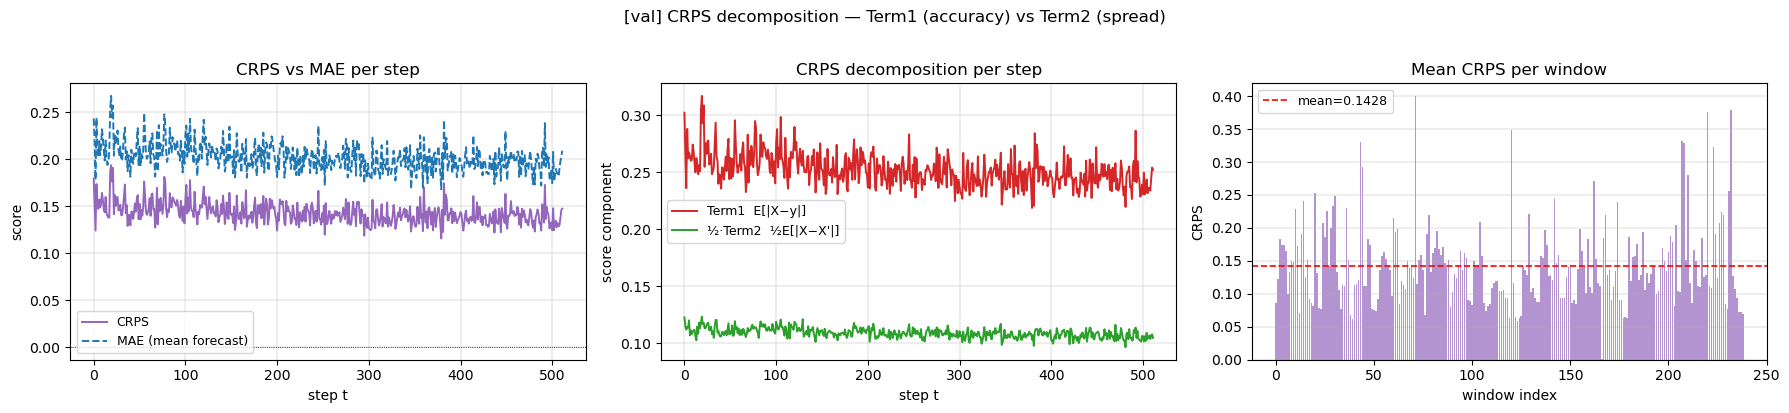

In [ ]:
def crps_ensemble_batch(samples, obs):
    """
    CRPS for every (window, step) position.

    Parameters
    ----------
    samples : (n_windows, n_samples, seq_len)
    obs     : (n_windows, seq_len)

    Returns
    -------
    crps  : (n_windows, seq_len)
    term1 : (n_windows, seq_len)  — E[|X - y|]
    term2 : (n_windows, seq_len)  — E[|X - X'|]
    """
    term1 = np.mean(np.abs(samples - obs[:, np.newaxis, :]), axis=1)

    n_windows_loc = samples.shape[0]
    term2 = np.zeros_like(term1)
    for w in range(n_windows_loc):
        s = samples[w]
        diff = np.abs(s[:, np.newaxis, :] - s[np.newaxis, :, :])
        term2[w] = diff.mean(axis=(0, 1))

    return term1 - 0.5 * term2, term1, term2

crps_grid, term1_grid, term2_grid = crps_ensemble_batch(gen_3d, gt_close)
mean_crps = float(crps_grid.mean())
mean_mae  = float(np.abs(gen_3d.mean(axis=1) - gt_close).mean())

print(f"Mean CRPS : {mean_crps:.5f}")
print(f"Mean MAE  : {mean_mae:.5f}   (CRPS of a perfect point forecast = MAE)")
print(f"Spread skill gap  (MAE − CRPS) : {mean_mae - mean_crps:.5f}  "
      f"({'positive → spread helps' if mean_mae > mean_crps else 'negative → spread hurts'})")
print()
print(f"Mean Term1  E[|X - y|]   : {term1_grid.mean():.5f}   (accuracy penalty)")
print(f"Mean Term2  E[|X - X'|]  : {term2_grid.mean():.5f}   (spread reward × 2)")
print(f"  → CRPS = Term1 − 0.5×Term2 = {term1_grid.mean():.5f} − {0.5*term2_grid.mean():.5f} = {mean_crps:.5f}")
print()

crps_per_step  = crps_grid.mean(axis=0)
term1_per_step = term1_grid.mean(axis=0)
term2_per_step = term2_grid.mean(axis=0)
mae_per_step   = np.abs(gen_3d.mean(axis=1) - gt_close).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(steps, crps_per_step,  color="tab:purple", lw=1.4, label="CRPS")
axes[0].plot(steps, mae_per_step,   color="tab:blue",   lw=1.4, label="MAE (mean forecast)", ls="--")
axes[0].axhline(0, color="black", lw=0.6, ls=":")
axes[0].set_title("CRPS vs MAE per step")
axes[0].set_xlabel("step t"); axes[0].set_ylabel("score")
axes[0].legend(fontsize=9); axes[0].grid(True, linewidth=0.3)

axes[1].plot(steps, term1_per_step,         color="tab:red",    lw=1.4, label="Term1  E[|X−y|]")
axes[1].plot(steps, 0.5 * term2_per_step,   color="tab:green",  lw=1.4, label="½·Term2  ½E[|X−X'|]")
axes[1].set_title("CRPS decomposition per step")
axes[1].set_xlabel("step t"); axes[1].set_ylabel("score component")
axes[1].legend(fontsize=9); axes[1].grid(True, linewidth=0.3)

crps_per_window = crps_grid.mean(axis=1)
axes[2].bar(np.arange(n_windows), crps_per_window, color="tab:purple", alpha=0.7)
axes[2].axhline(mean_crps, color="red", lw=1.2, ls="--", label=f"mean={mean_crps:.4f}")
axes[2].set_title("Mean CRPS per window")
axes[2].set_xlabel("window index"); axes[2].set_ylabel("CRPS")
axes[2].legend(fontsize=9); axes[2].grid(axis="y", linewidth=0.3)

plt.suptitle(f"[{ANALYSIS_SPLIT}] CRPS decomposition — Term1 (accuracy) vs Term2 (spread)", y=1.02)
plt.tight_layout()
display(fig)
plt.savefig(f"../images/final/edm/crps_decomposition_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)


## 11. Interval coverage — calibration check

For each nominal level $1-\alpha$ the empirical interval is $[q_{\alpha/2},\, q_{1-\alpha/2}]$ of the ensemble, computed per (window, step).

- **Empirical ≈ nominal** → well-calibrated uncertainty.  
- **Empirical < nominal** → overconfident (intervals too narrow).  
- **Empirical > nominal** → underconfident (intervals too wide).

Interval coverage  (empirical ≈ nominal → well-calibrated)
  gap > 0 → underconfident   |   gap < 0 → overconfident



,empirical,mean width,gap
nominal,,,
0.050000,0.0339,0.02566,-0.0161
0.100000,0.0674,0.05132,-0.0326
0.200000,0.1658,0.10375,-0.0342
0.300000,0.2315,0.15633,-0.0685
0.400000,0.3337,0.21168,-0.0663
0.500000,0.3998,0.26842,-0.1002
0.600000,0.5033,0.32911,-0.0967
0.700000,0.5705,0.39472,-0.1295
0.800000,0.6725,0.46464,-0.1275


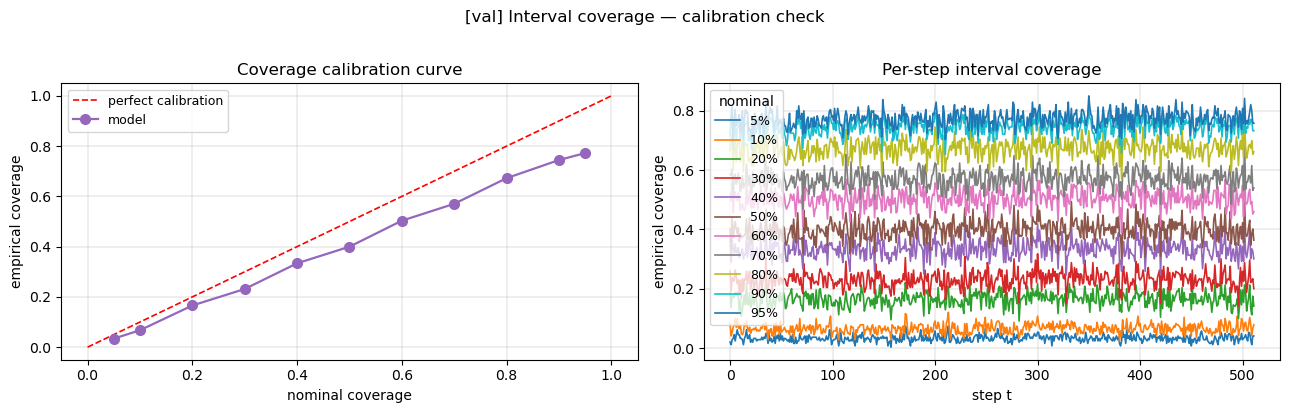

In [ ]:
COVERAGE_LEVELS = [0.05,0.1,0.2,0.3,0.4,0.50,0.6,0.7,0.8,0.90, 0.95]

rows = []
per_step_curves = {}

for level in COVERAGE_LEVELS:
    alpha = 1 - level
    # Empirical quantiles of the ensemble per (window, step)
    lo = np.quantile(gen_3d, alpha / 2,       axis=1)   # (n_windows, seq_len)
    hi = np.quantile(gen_3d, 1 - alpha / 2,   axis=1)   # (n_windows, seq_len)

    in_band          = (gt_close >= lo) & (gt_close <= hi)
    empirical        = float(in_band.mean())
    mean_width       = float((hi - lo).mean())
    per_step_curves[level] = in_band.mean(axis=0)        # (seq_len,) for the plot

    rows.append({
        "nominal"    : level,
        "empirical"  : round(empirical, 4),
        "mean width" : round(mean_width, 5),
        "gap"        : round(empirical - level, 4),
    })

df_cov = pd.DataFrame(rows)
print("Interval coverage  (empirical ≈ nominal → well-calibrated)")
print("  gap > 0 → underconfident   |   gap < 0 → overconfident\n")
display(df_cov.set_index("nominal").style.format(
    {"empirical": "{:.4f}", "mean width": "{:.5f}", "gap": "{:+.4f}"}
))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Calibration curve ─────────────────────────────────────────────────────────
nominals   = [r["nominal"]   for r in rows]
empiricals = [r["empirical"] for r in rows]
axes[0].plot([0, 1], [0, 1], "r--", lw=1.2, label="perfect calibration")
axes[0].plot(nominals, empiricals, "o-", color="tab:purple", lw=1.6, ms=7, label="model")
axes[0].set_xlabel("nominal coverage"); axes[0].set_ylabel("empirical coverage")
axes[0].set_title("Coverage calibration curve")
axes[0].legend(fontsize=9); axes[0].grid(True, linewidth=0.3)

# ── Per-step coverage for each level ─────────────────────────────────────────
for level, curve in per_step_curves.items():
    axes[1].plot(steps, curve, lw=1.2, label=f"{level:.0%}")
axes[1].set_xlabel("step t"); axes[1].set_ylabel("empirical coverage")
axes[1].set_title("Per-step interval coverage")
axes[1].legend(fontsize=9, title="nominal"); axes[1].grid(True, linewidth=0.3)

plt.suptitle(f"[{ANALYSIS_SPLIT}] Interval coverage — calibration check", y=1.02)
plt.tight_layout()
display(fig)
plt.savefig(f"../images/final/edm/interval_coverage_{appendix}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# plt.show()